Ethan Ho
017157582
CMPE 188

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import set_option
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFE
from numpy import set_printoptions
import seaborn as sns
from pandas.plotting import scatter_matrix

In [144]:
baseballData = pd.read_csv("E:/vs/school/CMPE_188/data/Baseball_salary.csv")
baseballData.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


## Cleaning
I decided to drop the catergorical columns of Unnamed, League, Division, and Newleague as they wont be able to contribute to the model. I also noticed some NaN values in the Salary coloumn which is not good since we will be using that to validate our output. In this case I will be using pandas' dropna function to remove those rows. Its difficult to tell the quality of the numerical cloumns so I'll save the cleaning of that for after the plotting of their histograms. Lastly I will also be logging the Salary coloumns in hopes of transforming the curve to a more symmetrical distribution.

In [145]:
df = baseballData.drop(["Unnamed: 0", "League", "Division", "NewLeague"], axis=1)
df['Salary'] = np.log(df['Salary'])
# df['Years'] = np.log(df['Years'])
# df['CAtBat'] = np.log(df['CAtBat'])
# df['CHits'] = np.log(df['CHits'])
# df['CHmRun'] = np.log(df['CHmRun'] + 1)
# df['CRuns'] = np.log(df['CRuns'])
# df['CRBI'] = np.log(df['CRBI'])
# df['CWalks'] = np.log(df['CWalks'])
# df['PutOuts'] = np.log(df['PutOuts'] + 1)
# df['Errors'] = np.log(df['Assists'] + 1)
df = df.dropna()
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,6.163315
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,6.173786
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,6.214608
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,4.516339
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,6.620073


## Histogram

It seems the each of the remaining columns have what seems to be most gaussian either with the mean right in the middle or a right skew. After normalization and/or standarization, they may come out looking better

[[<Axes: title={'center': 'AtBat'}> <Axes: title={'center': 'Hits'}>
  <Axes: title={'center': 'HmRun'}> <Axes: title={'center': 'Runs'}>]
 [<Axes: title={'center': 'RBI'}> <Axes: title={'center': 'Walks'}>
  <Axes: title={'center': 'Years'}> <Axes: title={'center': 'CAtBat'}>]
 [<Axes: title={'center': 'CHits'}> <Axes: title={'center': 'CHmRun'}>
  <Axes: title={'center': 'CRuns'}> <Axes: title={'center': 'CRBI'}>]
 [<Axes: title={'center': 'CWalks'}> <Axes: title={'center': 'PutOuts'}>
  <Axes: title={'center': 'Assists'}> <Axes: title={'center': 'Errors'}>]
 [<Axes: title={'center': 'Salary'}> <Axes: > <Axes: > <Axes: >]]


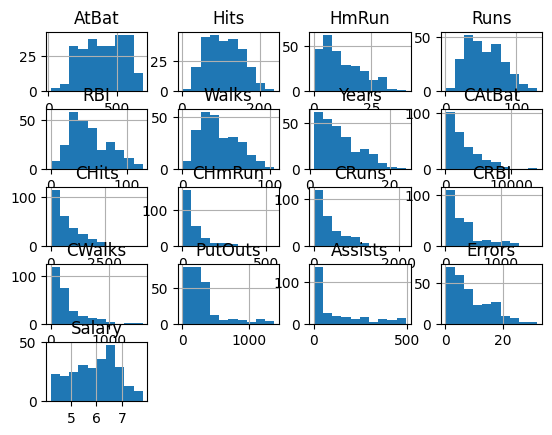

In [146]:
print(df.hist())

## Plotting Correlation Heatmap and Scatterplots

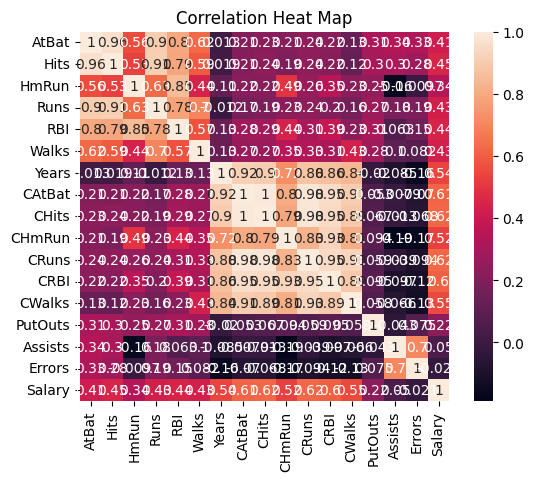

In [147]:
plt.figure()
correlationMap = df.corr(method='pearson')
sns.heatmap(correlationMap, square=True, annot=True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title("Correlation Heat Map")
plt.show()

<Figure size 640x480 with 0 Axes>

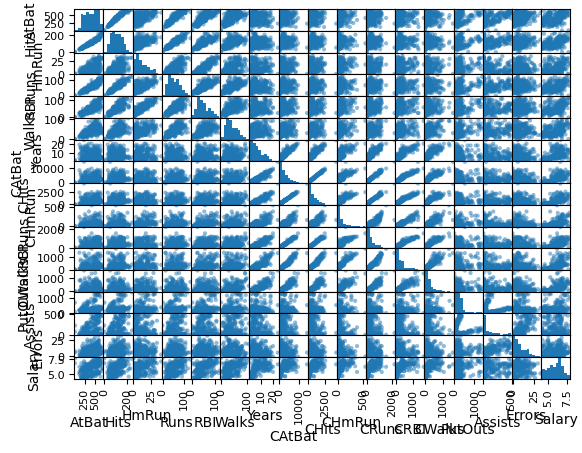

In [148]:
plt.figure()
scatter_matrix(df)
plt.show()

## Feature Selection



In [149]:
# Splitting the Data
X = df.drop(["Salary"], axis=1)
Y = df.drop(df.columns[0:16], axis=1)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print(x_test.head())
print(y_test.head())

     AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  \
148    497   136      7    58   38     26     11    3871   1066      40   
154    537   147     23    58   88     47     10    2744    730      97   
318    492   136      5    76   50     94     12    5511   1511      39   
279    439    96      0    44   36     65      4     711    148       1   
88     155    41     12    21   29     22     16    5409   1338     181   

     CRuns  CRBI  CWalks  PutOuts  Assists  Errors  
148    450   367     241      304      347      10  
154    302   351     174       92      257      20  
318    897   451     875      313      381      20  
279     68    56      99      229      406      22  
88     746   805     875      165        9       1  
       Salary
148  6.745236
154  5.625821
318  6.774224
279  5.010635
88   5.560682


In [150]:
# Building the model

scores = []
variance_arr = []
mse_arr = []

estimator = LinearRegression()
for i in range(1, len(df.columns)-1):

    multi_linear_reg = RFE(estimator, n_features_to_select=i)
    multi_linear_reg.fit(x_train, y_train)

    score = multi_linear_reg.score(x_test,y_test)
    scores.append(score)
    
    predicted_y = multi_linear_reg.predict(x_train)
    mse = mean_squared_error(y_train, predicted_y)
    mse_arr.append(mse)
    
    variance = np.var(predicted_y)
    variance_arr.append(variance)

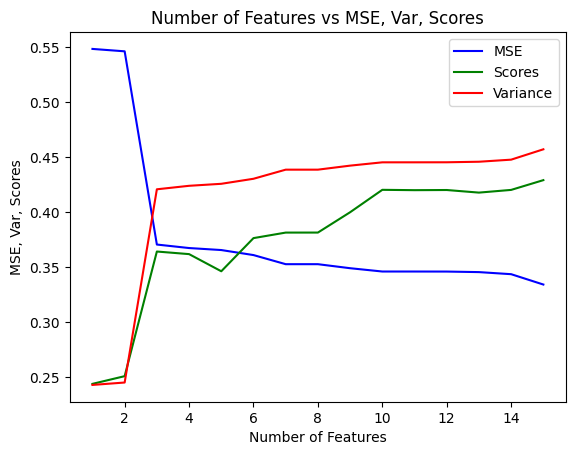

In [151]:
plt.figure()
plt.plot(range(1, len(mse_arr) + 1), mse_arr, color='blue', label='MSE')
plt.plot(range(1, len(scores) + 1), scores, color='green', label='Scores')
plt.plot(range(1, len(scores) + 1), variance_arr, color='red', label='Variance')
plt.xlabel('Number of Features')
plt.ylabel('MSE, Var, Scores')
plt.legend()
plt.title('Number of Features vs MSE, Var, Scores')
plt.show()

In [152]:
threeFeatureModel = RFE(estimator, n_features_to_select=3)
threeFeatureModel.fit(x_train, y_train)
score = threeFeatureModel.score(x_test, y_test)
features = threeFeatureModel.support_
selected_features = X.columns[features]
print(score, selected_features)

0.36407857769980334 Index(['Hits', 'Years', 'Errors'], dtype='object')


From the graph it seems like the model performs well at three features as that is where the error and variance intersect. We can also see the accuracy of the model steadyly increasing towards three and then it steadily increases likely due to overfitting. However it doesn't seem to be a very good model because the accuracy score does not go over 0.5.

In [153]:
# Turning the featuer engineering into a functuion

def featuerEngineering(xdata, ydata):
    x_train, x_test, y_train, y_test = train_test_split(xdata, ydata, test_size=0.3, random_state=42)
    scores = []
    variance_arr = []
    mse_arr = []

    estimator = LinearRegression()
    for i in range(1, len(df.columns)-1):

        multi_linear_reg = RFE(estimator, n_features_to_select=i)
        multi_linear_reg.fit(x_train, y_train)

        score = multi_linear_reg.score(x_test,y_test)
        scores.append(score)
        
        predicted_y = multi_linear_reg.predict(x_train)
        mse = mean_squared_error(y_train, predicted_y)
        mse_arr.append(mse)
        
        variance = np.var(predicted_y)
        variance_arr.append(variance)
    
    return scores, variance_arr, mse_arr
    

# Standardizing

In [154]:
scaler = StandardScaler().fit(X)
standarizedX = pd.DataFrame(scaler.transform(X), columns=X.columns)

array([[<Axes: title={'center': 'AtBat'}>,
        <Axes: title={'center': 'Hits'}>,
        <Axes: title={'center': 'HmRun'}>,
        <Axes: title={'center': 'Runs'}>],
       [<Axes: title={'center': 'RBI'}>,
        <Axes: title={'center': 'Walks'}>,
        <Axes: title={'center': 'Years'}>,
        <Axes: title={'center': 'CAtBat'}>],
       [<Axes: title={'center': 'CHits'}>,
        <Axes: title={'center': 'CHmRun'}>,
        <Axes: title={'center': 'CRuns'}>,
        <Axes: title={'center': 'CRBI'}>],
       [<Axes: title={'center': 'CWalks'}>,
        <Axes: title={'center': 'PutOuts'}>,
        <Axes: title={'center': 'Assists'}>,
        <Axes: title={'center': 'Errors'}>]], dtype=object)

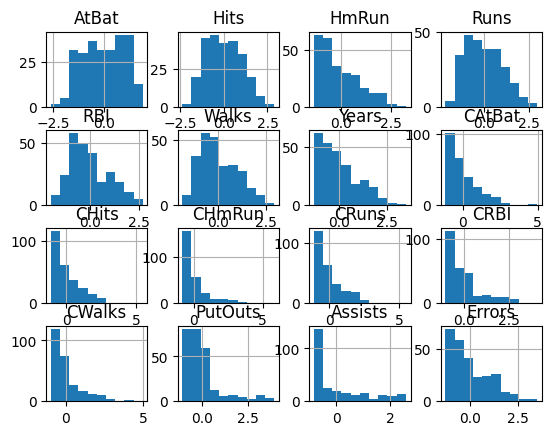

In [155]:
standarizedX.hist()

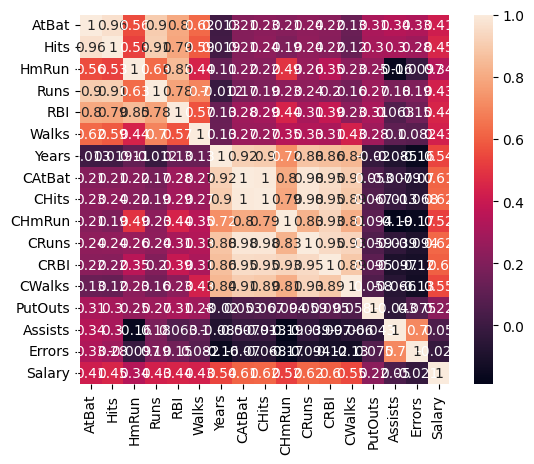

In [156]:
plt.figure()
correlationMap = df.corr(method='pearson')
sns.heatmap(correlationMap, square=True, annot=True)
plt.show()

<Figure size 640x480 with 0 Axes>

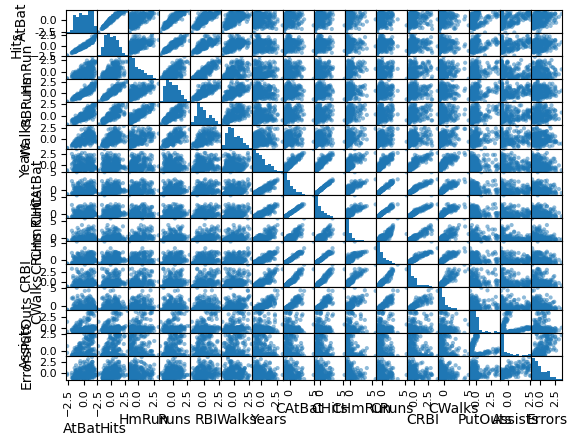

In [157]:
plt.figure()
scatter_matrix(standarizedX)
plt.show()

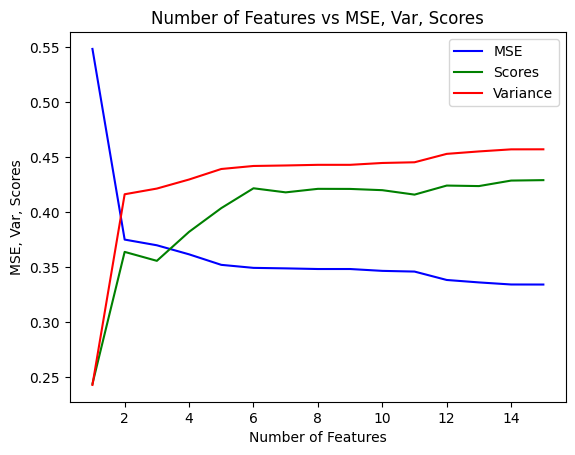

In [158]:
s, v, m = featuerEngineering(standarizedX, Y)
plt.figure()
plt.plot(range(1, len(mse_arr) + 1), m, color='blue', label='MSE')
plt.plot(range(1, len(scores) + 1), s, color='green', label='Scores')
plt.plot(range(1, len(scores) + 1), v, color='red', label='Variance')
plt.xlabel('Number of Features')
plt.ylabel('MSE, Var, Scores')
plt.legend()
plt.title('Number of Features vs MSE, Var, Scores')
plt.show()

# Normalizing

In [159]:
scaler = Normalizer().fit(X)
normalizedX = pd.DataFrame(scaler.transform(X), columns=X.columns)

array([[<Axes: title={'center': 'AtBat'}>,
        <Axes: title={'center': 'Hits'}>,
        <Axes: title={'center': 'HmRun'}>,
        <Axes: title={'center': 'Runs'}>],
       [<Axes: title={'center': 'RBI'}>,
        <Axes: title={'center': 'Walks'}>,
        <Axes: title={'center': 'Years'}>,
        <Axes: title={'center': 'CAtBat'}>],
       [<Axes: title={'center': 'CHits'}>,
        <Axes: title={'center': 'CHmRun'}>,
        <Axes: title={'center': 'CRuns'}>,
        <Axes: title={'center': 'CRBI'}>],
       [<Axes: title={'center': 'CWalks'}>,
        <Axes: title={'center': 'PutOuts'}>,
        <Axes: title={'center': 'Assists'}>,
        <Axes: title={'center': 'Errors'}>]], dtype=object)

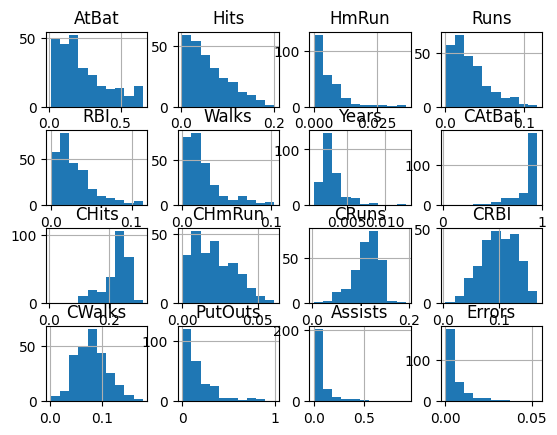

In [160]:
normalizedX.hist()

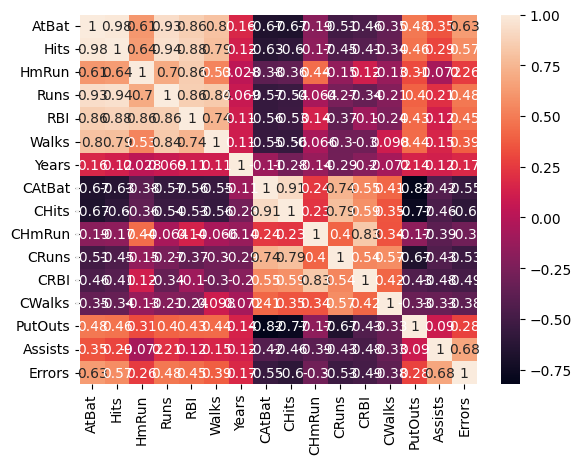

In [161]:
plt.figure()
corrMap = normalizedX.corr(method='pearson')
sns.heatmap(corrMap, annot=True)
plt.show()

<Figure size 640x480 with 0 Axes>

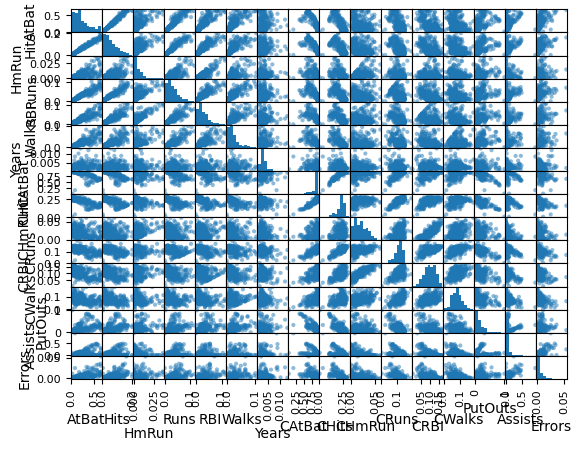

In [162]:
plt.figure()
scatter_matrix(normalizedX)
plt.show()

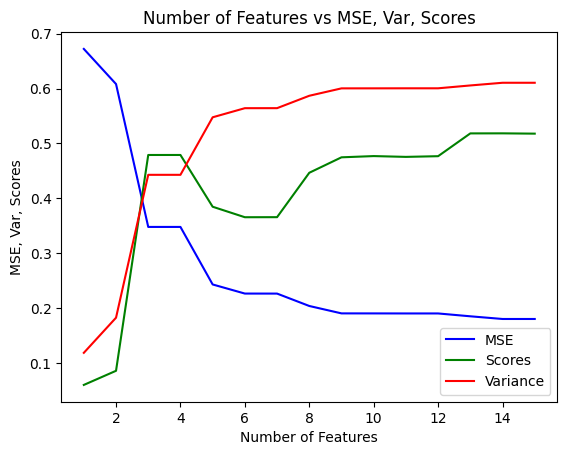

In [163]:
s, v, m = featuerEngineering(normalizedX, Y)
plt.figure()
plt.plot(range(1, len(mse_arr) + 1), m, color='blue', label='MSE')
plt.plot(range(1, len(scores) + 1), s, color='green', label='Scores')
plt.plot(range(1, len(scores) + 1), v, color='red', label='Variance')
plt.xlabel('Number of Features')
plt.ylabel('MSE, Var, Scores')
plt.legend()
plt.title('Number of Features vs MSE, Var, Scores')
plt.show()

After standizing and normalizing the data, there were only a few notable changes. The correlation heatmap and scatterplot for the standarized data was virtually the same. However after the RFE and the feature plot, it suggested 2 features rathar than the previous 3. In the case of the normalized graph, some of the originally symetrical distributions seemed to turn skewed and others vise versa. In the correlation map, some of the features began to have negative correlation but the RFE plot mainly stayed the same. 